## Improved Model Training with CAMeLBERT

This iteration shows significant improvements by switching to CAMeLBERT (`CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment`) and using a different emotions mapping and diffrent train/test datasets:

- **Key Changes**:
  - New base model: CAMeLBERT (pre-trained for Arabic sentiment)
  - Training on Video 1 (583 samples) → Testing on Video 2 (334 samples)
  - Using raw "Translation" column instead of corrected sentences
  - Reduced epochs (6) with higher learning rate (3e-5)

- **Performance Highlights**:
  - **Weighted F1: 0.7687** (substantial improvement from 0.543)
  - Best validation F1: 0.7687 (epoch 3)
  - Strong performance on neutral class (F1=0.91)
  - Challenges with minority classes (happiness, sadness, etc.)

- **Training Dynamics**:
  - Faster convergence (6 epochs vs 15 previously)
  - More stable validation loss (0.66-1.09 range)
  - Batch size increased to 32

- **Analysis**:
  - Model achieves 82% accuracy but shows bias toward majority class (neutral)
  - Confusion matrix reveals difficulty with emotion differentiation
  - Suggests need for class balancing or targeted augmentation

Note: The macro F1 (0.16) indicates poor performance on minority classes despite good weighted F1.

Train columns: Index(['Start Time', 'End Time', 'Sentence', 'Corrected Sentence',
       'Translation', 'Emotion', 'Intensity'],
      dtype='object')
Test columns: Index(['Start Time', 'End Time', 'Sentence', 'Corrected Sentence',
       'Translation', 'Emotion', 'Intensity'],
      dtype='object')


Map:   0%|          | 0/583 [00:00<?, ? examples/s]

Map:   0%|          | 0/334 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([7, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([7]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/tmp/ipykernel_11475/3446713679.py:124: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,F1
1,No log,1.090517,0.747777
2,No log,0.725224,0.747777
3,1.135400,0.704295,0.768664
4,1.135400,0.700611,0.747777
5,1.135400,0.744223,0.728888
6,0.693600,0.664692,0.744914


Evaluation Results: {'eval_loss': 0.7042952179908752, 'eval_f1': 0.7686640142533725, 'eval_runtime': 0.3761, 'eval_samples_per_second': 888.082, 'eval_steps_per_second': 29.248, 'epoch': 6.0}
Weighted F1 Score: 0.7687


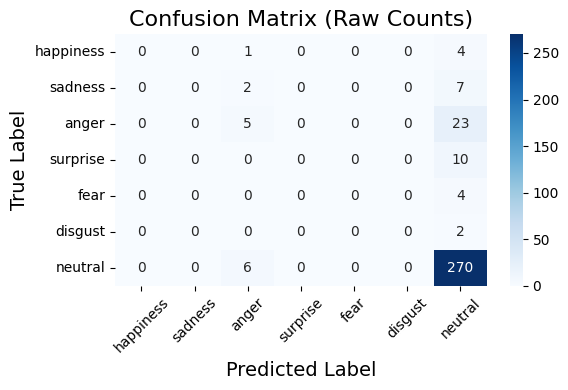

Classification Report:
               precision    recall  f1-score   support

   happiness       0.00      0.00      0.00         5
     sadness       0.00      0.00      0.00         9
       anger       0.36      0.18      0.24        28
    surprise       0.00      0.00      0.00        10
        fear       0.00      0.00      0.00         4
     disgust       0.00      0.00      0.00         2
     neutral       0.84      0.98      0.91       276

    accuracy                           0.82       334
   macro avg       0.17      0.17      0.16       334
weighted avg       0.73      0.82      0.77       334



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [2]:
import pandas as pd
import torch
import numpy as np
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments
from datasets import Dataset
import evaluate
from transformers import AutoConfig
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report  # Ensure scikit-learn is installed

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define model checkpoint
MODEL_CHECKPOINT = "CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment"

# Load training and test data
train_df = pd.read_csv(r"./group6_1.csv")
test_df = pd.read_csv(r"./group6_two.csv")

# Optional: print columns to verify
print("Train columns:", train_df.columns)
print("Test columns:", test_df.columns)

# Select only the required columns (assuming CSV has 'Translation' and 'Emotion' columns)
train_df = train_df[["Translation", "Emotion"]]
test_df = test_df[["Translation", "Emotion"]]

# Drop rows with missing values in the Translation or Emotion columns
train_df = train_df.dropna(subset=["Translation", "Emotion"])
test_df = test_df.dropna(subset=["Translation", "Emotion"])

# Emotion label mapping
label_map = {
    "happiness": 0,
    "sadness": 1,
    "anger": 2,
    "surprise": 3,
    "fear": 4,
    "disgust": 5,
    "neutral": 6
}

# Apply label mapping
train_df["label"] = train_df["Emotion"].map(label_map)
test_df["label"] = test_df["Emotion"].map(label_map)

# Drop rows with missing labels (if any emotion wasn't found in label_map)
train_df = train_df.dropna(subset=["label"])
test_df = test_df.dropna(subset=["label"])

# Convert labels to integer type
train_df["label"] = train_df["label"].astype(int)
test_df["label"] = test_df["label"].astype(int)

# Keep only needed columns: 'Translation' and 'label'
train_df = train_df[["Translation", "label"]]
test_df = test_df[["Translation", "label"]]

# Convert to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

# Tokenization function using the 'Translation' column
def tokenize_function(examples):
    return tokenizer(examples["Translation"], padding="max_length", truncation=True, max_length=128)

# Apply tokenization
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Remove unnecessary columns (remove the 'Translation' column)
train_dataset = train_dataset.remove_columns(["Translation"])
test_dataset = test_dataset.remove_columns(["Translation"])

# Set dataset format for PyTorch
train_dataset.set_format("torch")
test_dataset.set_format("torch")

# Load pre-trained model configuration and set problem type for single-label classification
config = AutoConfig.from_pretrained(MODEL_CHECKPOINT, num_labels=len(label_map))
config.problem_type = "single_label_classification"

# Load pre-trained model (classifier head resized from 3 to 7 classes)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    config=config,
    ignore_mismatched_sizes=True  # Fixes size mismatch error
)
model.to(device)

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results_12",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=6,
    weight_decay=0.01,
    warmup_steps=100,
    lr_scheduler_type="linear",
    logging_dir="./logs_v2",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2,
)

# Load evaluation metric (using weighted F1 score)
metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels, average="weighted")

# Define Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

# Train model
trainer.train()

# Save trained model
model.save_pretrained("./train_test_agency")
tokenizer.save_pretrained("./train_test_agency")

# Evaluate model
eval_results = trainer.evaluate()
print("Evaluation Results:", eval_results)
print("Weighted F1 Score: {:.4f}".format(eval_results['eval_f1']))

# --- Confusion Matrix Section ---
# Generate predictions on the test dataset
predictions_output = trainer.predict(test_dataset)
preds = np.argmax(predictions_output.predictions, axis=1)
true_labels = predictions_output.label_ids

# Compute the confusion matrix without normalization
cm = confusion_matrix(true_labels, preds)

# Plot the Confusion Matrix using Seaborn
ordered_labels = [k for k, v in sorted(label_map.items(), key=lambda item: item[1])]
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=ordered_labels, yticklabels=ordered_labels)
plt.title("Confusion Matrix (Raw Counts)", fontsize=16)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# --- Classification Report ---
report = classification_report(true_labels, preds, target_names=ordered_labels)
print("Classification Report:\n", report)